In [1]:
import numpy as np
import pandas as pd

import scipy

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [2]:
## 5kb.
####### 需要测试集的Label和Prediction score.
file = '/data/xujs/Project/HiC2PoreC/code/H2P/results/HiPore-C_GM12878_5kb/HiPore-C_GM12878_5kb_test_chr1/HiPore-C_GM12878_5kb_test_chr1_ND_SNS_Struc_r0.tsv'

df = pd.read_table(file)

pos = df.loc[df['Label'] == 1.0, 'Pred']
neg = df.loc[df['Label'] == 0.0, 'Pred']

num = min(len(pos), len(neg))
pos = np.random.choice(pos, num)
neg = np.random.choice(neg, num)

kl = scipy.stats.entropy(pos, neg)

kl = round(kl, 4)

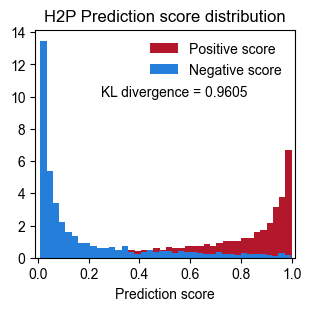

In [183]:
fig, axes = plt.subplots(1, 1, figsize=(3, 3), constrained_layout=True)
# axes = axes.flatten()

#### 1. H2P
# sns.distplot(pos_, bins=100, hist=True, kde=False, rug=False, vertical=False, norm_hist=True)
n1, bins1, patches1 = axes.hist(pos, bins=40, density=True, color='#b3172c', label='Positive score', alpha=1)
n2, bins2, patches2 = axes.hist(neg, bins=40, density=True, color='#247eda', label='Negative score', alpha=1)

# axes.plot(bins1[:-1], n1, '-', color='#b3172c', label='Positive score', lw=1)
# axes.plot(bins2[:-1], n2, '-', color='#247eda', label='Negative score', lw=1)

axes.legend(loc='upper right', frameon=False)
axes.set_xlim([-0.01, 1.01])
# axes.set_ylim([0,1])
# axes.set_xticks([0, 0.5, 1.0])
# axes.set_yticks([0, 0.5, 1.0])
axes.set_xlabel('Prediction score')
axes.set_ylabel('')
axes.text(0.25, 10, f'KL divergence = {kl}')
axes.set_title('H2P Prediction score distribution')
fig.savefig('./H2P_KL_divergene.histPlot.pdf')

In [3]:
def calc_kl_divergence(file, min_size=3, max_size=7, pl=0.001, ph=0.999):
    pos = df.loc[(df['Size'] <= max_size) & (df['Label'] == 1.0), 'Pred']
    neg = df.loc[(df['Size'] <= max_size) & (df['Label'] == 0.0), 'Pred']

    pos = pos[(pos>pl) & (pos<ph)]
    neg = neg[(neg>pl) & (neg<ph)]

    num = min(len(pos), len(neg))
    pos = np.random.choice(pos, num)
    neg = np.random.choice(neg, num)

    kl = scipy.stats.entropy(pos, neg)

    kl = round(kl, 4)

    return kl, pos, neg

In [3]:
test_chr = 'chr1'
data_dir = f'/data/xujs/Project/HiC2PoreC/code/H2P/results/HiPore-C_GM12878_5kb/HiPore-C_GM12878_5kb_test_{test_chr}'

kl_H2P,    pos_H2P,    neg_H2P = calc_kl_divergence(file=f'{data_dir}/HiPore-C_GM12878_5kb_test_{test_chr}_ND_MIX_Struc_r0.tsv', pl=0.01, ph=0.99)
kl_EpiH2P, pos_EpiH2P, neg_EpiH2P = calc_kl_divergence(file=f'{data_dir}/HiPore-C_GM12878_5kb_test_{test_chr}_ND_MIX_StrucEpi_r0.tsv', pl=0.007, ph=0.99)
kl_SeqH2P, pos_SeqH2P, neg_SeqH2P = calc_kl_divergence(file=f'{data_dir}/HiPore-C_GM12878_5kb_test_{test_chr}_ND_MIX_StrucSeq_r0.tsv', pl=0.0073, ph=0.99)
kl_ESH2P,  pos_ESH2P,  neg_ESH2P = calc_kl_divergence(file=f'{data_dir}/HiPore-C_GM12878_5kb_test_{test_chr}_ND_MIX_StrucEpiSeq_r0.tsv', pl=0.006, ph=0.99)


In [7]:
chroms = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22']

kl_H2P_list = []
kl_EpiH2P_list = []
kl_SeqH2P_list = []
kl_ESH2P_list = []

for test_chr in chroms:
    data_dir = f'/data/xujs/Project/HiC2PoreC/code/H2P/results/HiPore-C_GM12878_5kb/HiPore-C_GM12878_5kb_test_{test_chr}'
    kl_H2P,    pos_H2P,    neg_H2P = calc_kl_divergence(file=f'{data_dir}/HiPore-C_GM12878_5kb_test_{test_chr}_ND_MIX_Struc_r0.tsv', pl=0.01, ph=0.99)
    kl_EpiH2P, pos_EpiH2P, neg_EpiH2P = calc_kl_divergence(file=f'{data_dir}/HiPore-C_GM12878_5kb_test_{test_chr}_ND_MIX_StrucEpi_r0.tsv', pl=0.007, ph=0.99)
    kl_SeqH2P, pos_SeqH2P, neg_SeqH2P = calc_kl_divergence(file=f'{data_dir}/HiPore-C_GM12878_5kb_test_{test_chr}_ND_MIX_StrucSeq_r0.tsv', pl=0.0072, ph=0.99)
    kl_ESH2P,  pos_ESH2P,  neg_ESH2P = calc_kl_divergence(file=f'{data_dir}/HiPore-C_GM12878_5kb_test_{test_chr}_ND_MIX_StrucEpiSeq_r0.tsv', pl=0.006, ph=0.99)

    kl_H2P_list.append(kl_H2P)
    kl_EpiH2P_list.append(kl_EpiH2P)
    kl_SeqH2P_list.append(kl_SeqH2P)
    kl_ESH2P_list.append(kl_ESH2P)\

df_model_kl = pd.DataFrame({
                'Model': ['H2P']*len(chroms) + ['Epi-H2P']*len(chroms) +  ['Seq-H2P']*len(chroms) +  ['ES-H2P']*len(chroms),
                'Chrom': chroms * 4,
                'KL_score': kl_H2P_list + kl_EpiH2P_list + kl_SeqH2P_list + kl_ESH2P_list,
            })

/tmp/ipykernel_32047/4084821720.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(axes.get_xticklabels(), rotation=30)


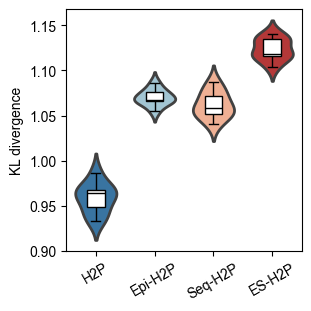

In [166]:
fig, axes = plt.subplots(1, 1, figsize=(3, 3), constrained_layout=True)
# axes = axes.flatten()

model_color_dict = {'H2P': '#2877b2',
                    'Epi-H2P': '#9ac9db',
                    'Seq-H2P': '#feaa85',
                    'ES-H2P': '#c92323'}

sns.boxplot(x='Model', y='KL_score', data=df_model_kl, ax=axes, linewidth=1, linecolor='black', width=.3, color='white', fliersize=0)
sns.violinplot(x='Model', y='KL_score', data=df_model_kl, hue='Model', inner=None, ax=axes, linewidth=2, width=.7, palette=model_color_dict)

# axes.set_ylim([0.9, 1.2])
axes.set_xlabel('')
axes.set_xticklabels(axes.get_xticklabels(), rotation=30)
axes.set_ylabel('KL divergence')

fig.savefig('./Model_Variants_KL_divergene.violinPlot.pdf')